# 🧠 EDA Notebook
This notebook teaches Exploratory Data Analysis step by step, with explanations.

## 📦 1. Setup & Sample Data
We create a dataset with missing values and outliers to simulate real-world data.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 200

df = pd.DataFrame({
    "age": np.random.randint(18, 70, n),
    "salary": np.random.normal(50000, 15000, n),
    "gender": np.random.choice(["Male", "Female"], n),
    "department": np.random.choice(["IT", "HR", "Finance", "Sales"], n),
    "experience_years": np.random.randint(0, 40, n)
})

# Introduce missing values
df.loc[np.random.choice(df.index, 20), "salary"] = np.nan
df.loc[np.random.choice(df.index, 15), "gender"] = np.nan

# Introduce outliers
df.loc[0, "salary"] = 200000
df.loc[1, "salary"] = 5

df.head(25)

,age,salary,gender,department,experience_years
0,56,200000.000000,Male,IT,1
1,69,5.000000,Male,IT,12
2,46,79176.734217,Female,HR,10
3,32,47699.953137,Female,HR,22
4,60,36395.191619,Male,Finance,15
5,25,37739.687673,Male,Sales,30
6,38,42753.159819,Male,Finance,10
7,56,41452.574774,Male,IT,15
8,36,18626.004955,Female,Finance,7
9,40,68956.107961,Female,Sales,3


## 🔍 2. First Look
We explore the structure of the dataset.

### Shape
👉 WHY: To understand how many rows (records) and columns (features) we have.

In [5]:
df.shape

(200, 5)

### Data Types
👉 WHY: Helps us distinguish between numerical and categorical columns.

In [6]:
df.dtypes

age                   int32
salary              float64
gender                  str
department              str
experience_years      int32
dtype: object

### Info
👉 WHY: Shows missing values and confirms data types.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               200 non-null    int32  
 1   salary            183 non-null    float64
 2   gender            186 non-null    str    
 3   department        200 non-null    str    
 4   experience_years  200 non-null    int32  
dtypes: float64(1), int32(2), str(2)
memory usage: 6.4 KB


### Describe
👉 WHY: Provides summary statistics (mean, min, max) useful for spotting anomalies.

In [8]:
df.describe()

,age,salary,experience_years
count,200.00000,183.000000,200.000000
mean,43.42500,51059.322407,18.770000
std,14.94191,19586.767975,11.843498
min,18.00000,5.000000,0.000000
25%,31.00000,39819.349986,8.000000
50%,43.50000,49929.560080,19.000000
75%,56.00000,62434.091666,29.000000
max,69.00000,200000.000000,39.000000


## ❗ 3. Missing Values
👉 WHY: Missing data can break models and analysis.

In [9]:
# function to check missing values (1)
def check_missing_values(df):
    plt.figure(figsize=(7, 7))
    null_in_data_set = df.isnull().sum()
    null_in_data_set = null_in_data_set[null_in_data_set > 0]
    null_in_data_set.sort_values(inplace=True)
    null_in_data_set.plot.bar()

# function to check missing values (2)
def check_missing_values_heat_map(df, legend = False):
    plt.figure(figsize=(16, 16))
    sns.heatmap(df.isnull(), cbar=legend)

# function to view missing values in a table format (3)
def table_view_of_missing_values(df):
    total = df.isnull().sum().sort_values(ascending=False)
    percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
    return missing_data[missing_data['Total'] > 0]

In [10]:
df.isnull().sum()

age                  0
salary              17
gender              14
department           0
experience_years     0
dtype: int64

In [11]:
# Explanation of missing values
"""
np.random.choice samples with replacement by default,
meaning it can pick the same row index multiple times.
When the same index is selected twice, it still only creates one null value.

For example, if index 42 is chosen 3 times out of your 20 picks,
only 1 null is created — not 3.
"""

'\nnp.random.choice samples with replacement by default,\nmeaning it can pick the same row index multiple times.\nWhen the same index is selected twice, it still only creates one null value.\n\nFor example, if index 42 is chosen 3 times out of your 20 picks,\nonly 1 null is created — not 3.\n'

Check missing values per row.

In [12]:
# Count of missing values per row
df.isnull().sum(axis=1).value_counts()

0    170
1     29
2      1
Name: count, dtype: int64

In [13]:
"""
0    170    # 170 rows have 0 missing values
1     29    # 29 rows have 1 missing value
2      1    # 1 row has 2 missing values
"""

'\n0    170    # 170 rows have 0 missing values\n1     29    # 29 rows have 1 missing value\n2      1    # 1 row has 2 missing values\n'

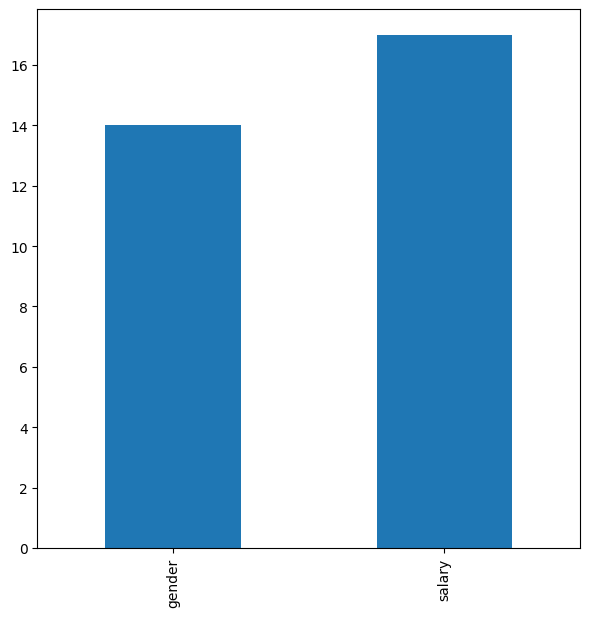

In [14]:
check_missing_values(df)

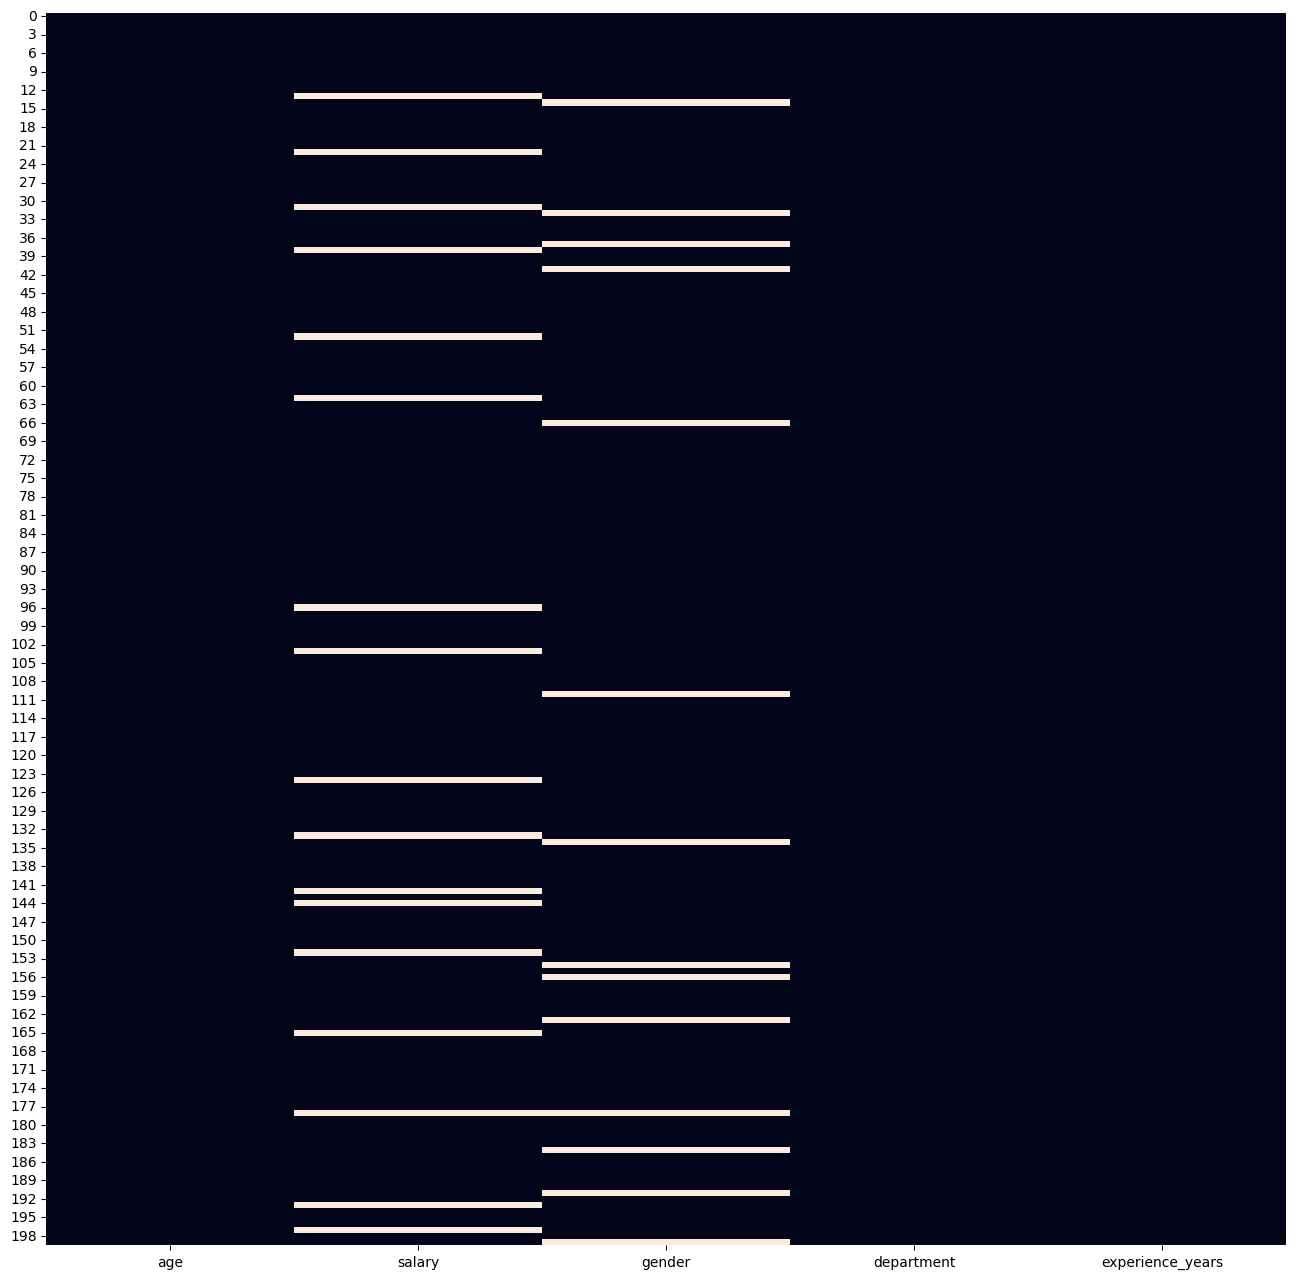

In [15]:
check_missing_values_heat_map(df)

In [16]:
table_view_of_missing_values(df)

,Total,Percent
salary,17,0.085
gender,14,0.070


## 🔧 4. Imputation
We fill missing values.

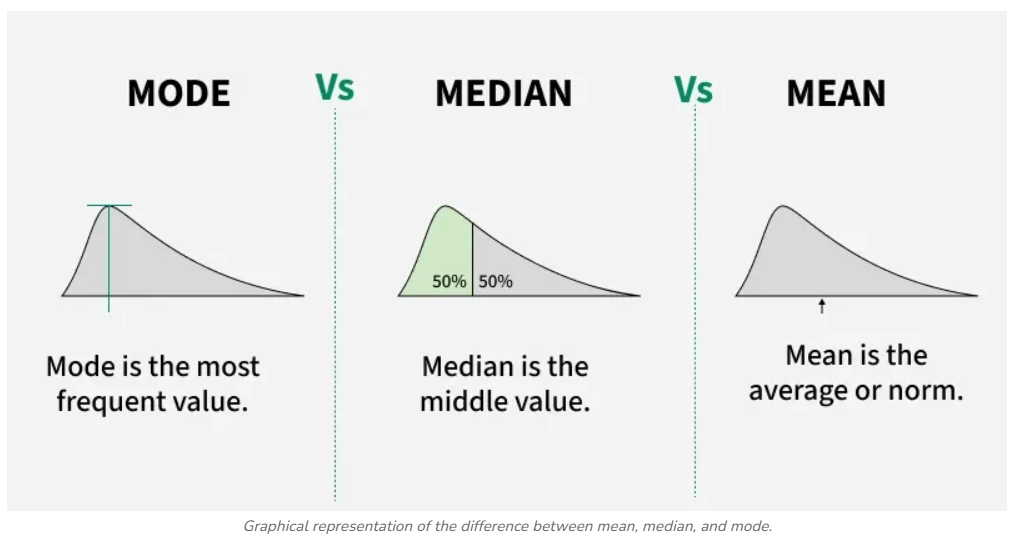

### Median Imputation (Numerical)
👉 WHY: Median is robust to outliers.

In [17]:
df["salary"].fillna(df["salary"].median(), inplace=True)

C:\Users\valentina.momchilova\AppData\Local\Temp\ipykernel_42472\1888323026.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["salary"].fillna(df["salary"].median(), inplace=True)


0      200000.000000
1           5.000000
2       79176.734217
3       47699.953137
4       36395.191619
           ...      
195     69228.805705
196     49573.678136
197     49929.560080
198     34355.579096
199     69897.075025
Name: salary, Length: 200, dtype: float64

### Mode Imputation (Categorical)
👉 WHY: Most frequent category is a reasonable guess.

In [18]:
df["gender"].mode()

0    Male
Name: gender, dtype: str

In [19]:
df["gender"].fillna(df["gender"].mode()[0], inplace=True)

C:\Users\valentina.momchilova\AppData\Local\Temp\ipykernel_42472\4193680292.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["gender"].fillna(df["gender"].mode()[0], inplace=True)


0        Male
1        Male
2      Female
3      Female
4        Male
        ...  
195      Male
196      Male
197    Female
198      Male
199      Male
Name: gender, Length: 200, dtype: str

## 🔢 5. Column Types

In [20]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

num_cols, cat_cols

(Index(['age', 'salary', 'experience_years'], dtype='str'),
 Index(['gender', 'department'], dtype='str'))

## 📊 6. Value Counts
👉 WHY: Understand distribution of categorical data.

In [21]:
df["department"].value_counts() # grouping by department to see the distribution of employees across departments

department
IT         59
HR         55
Sales      44
Finance    42
Name: count, dtype: int64

## 📈 7. Histogram
👉 WHY: Shows distribution of a numerical variable.

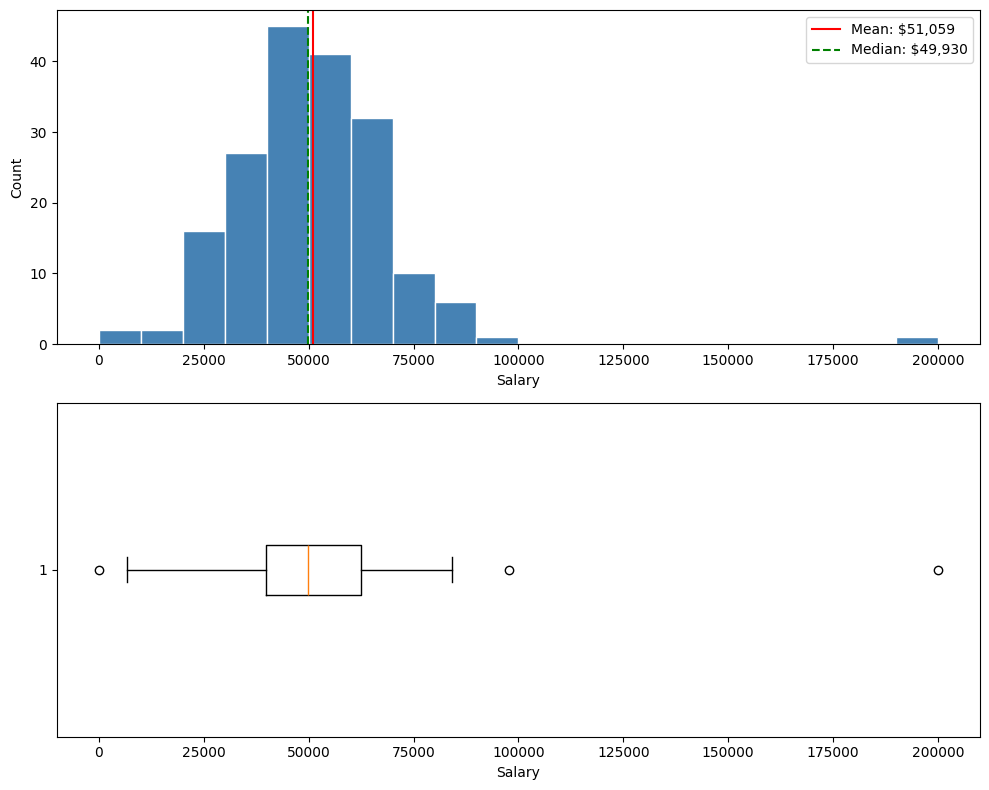

In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# histogram
ax1.hist(df['salary'], bins=20, color='steelblue', edgecolor='white')
ax1.axvline(df['salary'].mean(), color='red', label=f"Mean: ${df['salary'].mean():,.0f}")
ax1.axvline(df['salary'].median(), color='green', linestyle='--', label=f"Median: ${df['salary'].median():,.0f}")
ax1.set_xlabel('Salary')
ax1.set_ylabel('Count')
ax1.legend()

# box plot
ax2.boxplot(df['salary'].dropna(), vert=False)
ax2.set_xlabel('Salary')

plt.tight_layout()
plt.show()

Salary is likely right-skewed — the mean ($51k) is higher than the median ($49.9k),

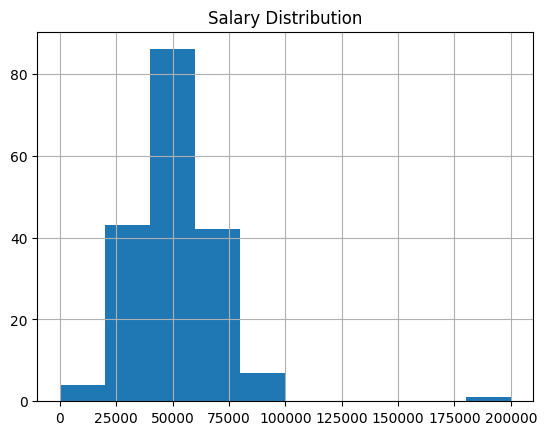

In [23]:
df["salary"].hist()
plt.title("Salary Distribution")
plt.show()

## 📦 8. Box Plot
👉 WHY: Detect outliers visually.

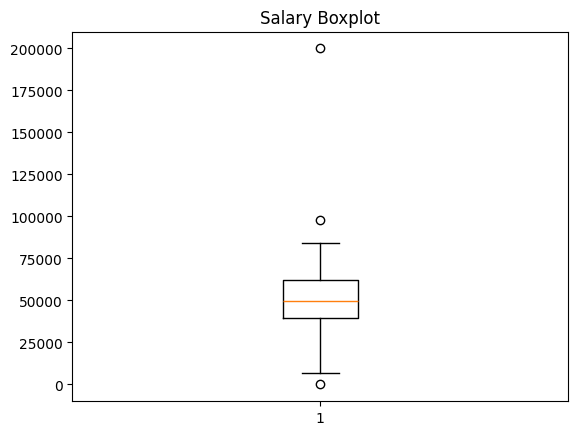

In [24]:
plt.boxplot(df["salary"].dropna())
plt.title("Salary Boxplot")
plt.show()

## 🚨 9. Outliers Detection

In [25]:
Q1 = df["salary"].quantile(0.25)
Q3 = df["salary"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

lower, upper

(np.float64(5897.237466198196), np.float64(96356.20418634902))

### Trim vs Cap
👉 Trim: remove outliers
👉 Cap: limit extreme values

In [26]:
# Trim
df_trimmed = df[(df["salary"] >= lower) & (df["salary"] <= upper)]

In [27]:
# Cap
df["salary"] = np.where(df["salary"] > upper, upper, df["salary"])
df["salary"] = np.where(df["salary"] < lower, lower, df["salary"])

## 🔄 10. Change Data Types
👉 WHY: Fix incorrect types or prepare for modeling.

In [28]:
df["age"] = df["age"].astype(float)

## 📊 11. Bivariate Analysis
👉 Compare two variables.

In [29]:
df.groupby("gender")["salary"].mean()

gender
Female    51486.229181
Male      49256.007626
Name: salary, dtype: float64

## 📊 12. Pivot Table (Multivariate)
👉 Analyze multiple variables together.

In [30]:
pivot = df.pivot_table(
    values="salary",
    index="department",
    columns="gender",
    aggfunc="mean"
)

pivot

gender,Female,Male
department,,
Finance,47294.092899,46028.832912
HR,53313.510541,52291.737147
IT,50489.822554,49427.161775
Sales,53282.721067,49498.738263


In [31]:
df.head()

,age,salary,gender,department,experience_years
0,56.0,96356.204186,Male,IT,1
1,69.0,5897.237466,Male,IT,12
2,46.0,79176.734217,Female,HR,10
3,32.0,47699.953137,Female,HR,22
4,60.0,36395.191619,Male,Finance,15


## 🔥 13. Heatmap (Correlation Matrix)
👉 WHY: Shows relationships between numerical variables.
Strong correlation means variables move together.

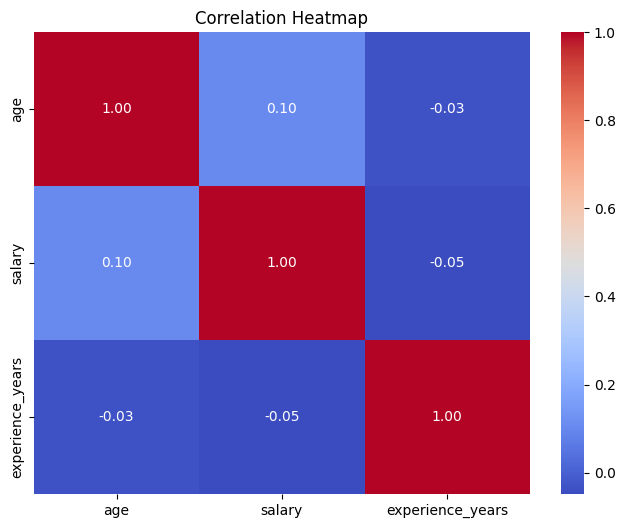

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap")
plt.show()

### Q: Does salary increase with age?

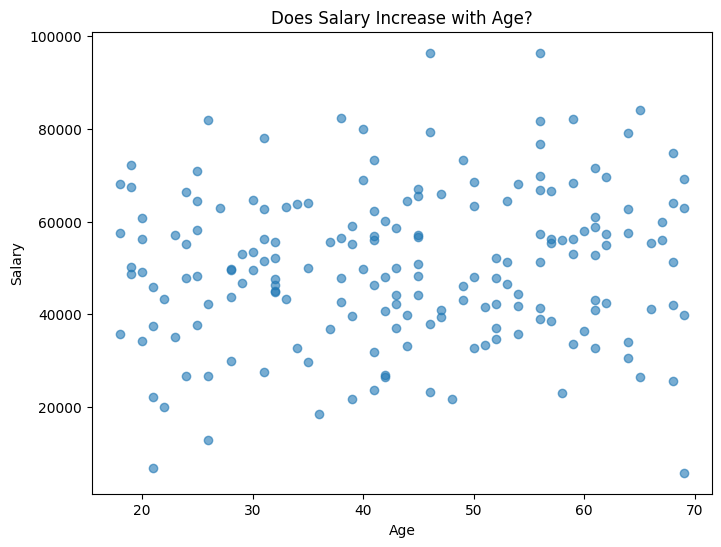

In [33]:
plt.figure(figsize=(8, 6))
plt.scatter(df["age"], df["salary"], alpha=0.6)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Does Salary Increase with Age?")
plt.show()

In [34]:
# In our randomly generated dataset, the correlation is likely weak
# because salary was randomly distributed without being tied to age.

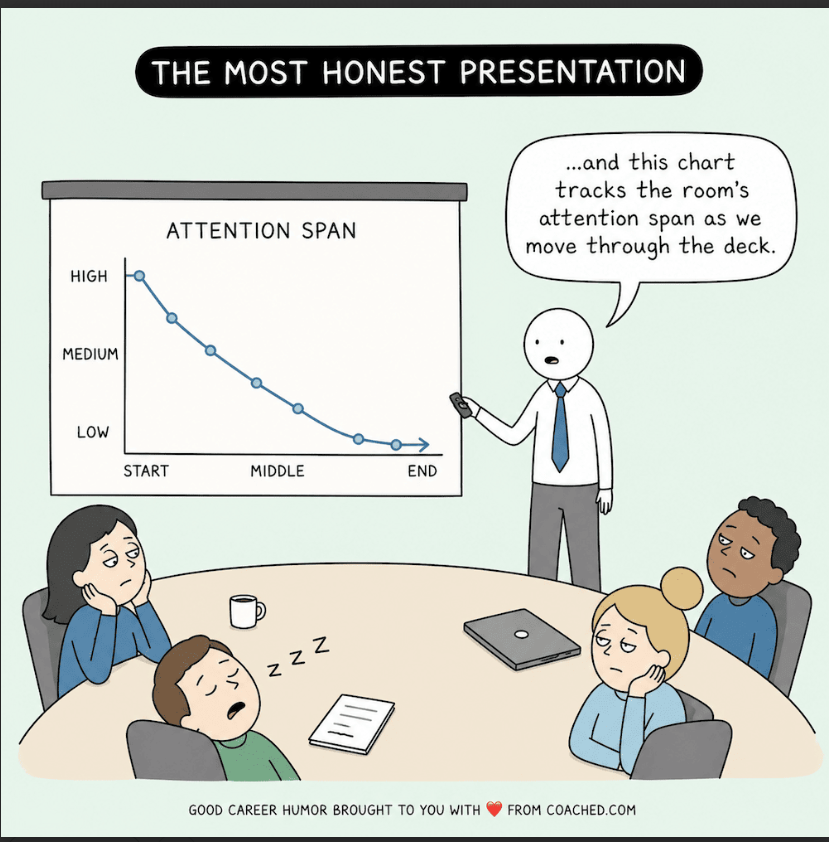